# Regression on Instagram

### The "Why" of exercise

To understand **trends** on social networks, it is important to be able to **assess the impact of a message** on the people who receive it. A message can be, for example, an Instagram post, a tweet, a tiktok video... There are two main ways to quantify the impact of a message:

1. by estimating the number of people who viewed the message
2. by counting the number of people who will actively adhere to the message by signaling their support, typically by "liking"

This second way is very powerful for understanding trends on social networks. It is useful both for observers (opinion leaders, experts, researchers, etc.) and influencers (digital marketing, prevention campaigns, etc.).

### The "What"

In this exercise, we will focus on posts on Instagram. Our goal is to model the number of `likes` that can be expected on a message, depending on the characteristics of the account sending the message.

To achieve this objective, we will decipher the influence of various variables (number of followers, account age, account activity, etc.).

In particular, quantifying the relationship between followers and likes makes it possible to estimate how many likes each additional follower generates on average. This gives the statistical "conversion rate" of followers to likes.

The dataset comes from [heuritech.com](Heuritech), a startup specializing in predicting clothing fashion trends from social networks.

### The "How"

We seek to quantify the relationship between several continuous variables: it is therefore a **regression problem**.

We will adopt the classic approach:

1. loading the dataset

2. exploring

3. separation into train and test

4. Modeling on the train

5. application on the test

## 1. Loading the dataset

<b>1.A)</b> Load the `posts.csv.bz` file, in the form of a `DataFrame` called `posts`. You can download the data at this [address](https://drive.google.com/file/d/1O8ey3uytjqzRUQXTnmXkiqGBoa6lne1C/view?usp=sharing).

We will use the **compression='bz2'** argument of the pandas read_csv function.

In [158]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn import linear_model
from sklearn import metrics
from math import sqrt

In [159]:
posts = pd.read_csv(
    "posts.csv.bz",
    compression="bz2",
).rename(columns={"id": "author_id"})
display(posts)
posts.describe().apply(lambda x: x.apply("{0:.1f}".format))

,author_id,followers,comments,posts,likes,ts
0,6e56f910,1804,2,851,73,2017-10-08 16:21:28
1,0bea9208,542,1,846,7,2017-07-07 11:58:18
2,88ec6c3f,669,2,1495,33,2018-03-19 17:22:29
3,006b0d03,757,9,144,166,2018-09-02 18:49:52
4,c8a0f2a6,539,4,453,71,2018-04-18 14:15:36
...,...,...,...,...,...,...
2260897,f58b19ab,1847,14,678,166,2018-09-10 15:02:43
2260898,58433abf,237,1,192,31,2018-10-13 10:02:59
2260899,10c4b02c,267,2,110,35,2018-09-18 22:42:03
2260900,0f7064e1,214,3,53,50,2018-11-01 11:32:57


,followers,comments,posts,likes
count,2260902.0,2260902.0,2260902.0,2260902.0
mean,872.5,1.9,673.3,48.1
std,489.6,3.2,492.1,40.2
min,1.0,0.0,1.0,0.0
25%,462.0,0.0,277.0,18.0
50%,801.0,1.0,544.0,36.0
75%,1228.0,3.0,976.0,66.0
max,1999.0,39.0,1998.0,199.0


<b>1.B)</b> How many posts and authors are there in this dataset?

In [160]:
#print(posts[posts.author_id == "6e56f910"])
display(f"Number of posts (len(post)):{len(posts)}")
display(f"Number of authors (author_id): {posts.author_id.nunique()}")

'Number of posts (len(post)):2260902'

'Number of authors (author_id): 9298'

1.C) This dataset contains multiple posts per author.

**Delete part of the data so as to keep only the last message posted chronologically, for each author.**

This avoids biases related to the over-representation of certain authors in our dataset, while using the most recent data.

<details>
<summary><i>Click for a hint</i></summary>
    ⟿ you can use the pandas functions `sort_values` and `drop_duplicates` with the keep argument to specify which duplicate element to keep.
</details>

In [161]:
# Clean posts by only keeping the last message posted by each author
# 1. Order the message per "ts" (date)
posts = posts.sort_values(by="ts", ascending=True)
# 2. Delete duplicate ids
posts = posts.drop_duplicates(subset=["author_id"], keep="last")
display(posts)

,author_id,followers,comments,posts,likes,ts
1955601,c43f3233,1532,2,76,177,2016-03-26 20:15:50
145849,38cc9619,1395,10,152,192,2016-04-01 14:53:58
66276,58ce1b8d,582,1,80,32,2016-06-23 12:28:21
1922869,0dd11d6c,1566,0,57,150,2016-07-24 19:29:49
563184,688eb92e,1675,1,159,166,2016-08-24 21:15:57
...,...,...,...,...,...,...
1747502,bd90c5ec,840,1,120,107,2019-03-10 23:53:48
673328,2e246173,582,2,12,27,2019-03-10 23:53:54
1860496,b0817588,1751,0,704,23,2019-03-10 23:54:41
1883069,4bdf6fc3,1250,2,303,42,2019-03-10 23:57:42


<b>1.D)</b> Re-calculate the number of authors and posts in the dataset to verify that you now have a single post per author.

In [162]:
display(f"Number of posts (len(post)):{len(posts)}")
display(f"Number of authors (author_id): {posts.author_id.nunique()}")

'Number of posts (len(post)):9298'

'Number of authors (author_id): 9298'

## 2. Explore

<b>2.A)</b> Let's start with the eagle view: the "pair-plot", which allows to visualize the distribution of each variable (on the diagonal) and its relation with the other variables (other graphs of the line).

Display this pair-plot on a subsample corresponding to 10% of the dataset.

<details>
<summary><i>Click for a hint</i></summary>
    ⟿ You can use the `pairplot` function of the `seaborn` module: https://seaborn.pydata.org/generated/seaborn.pairplot.html
</details>

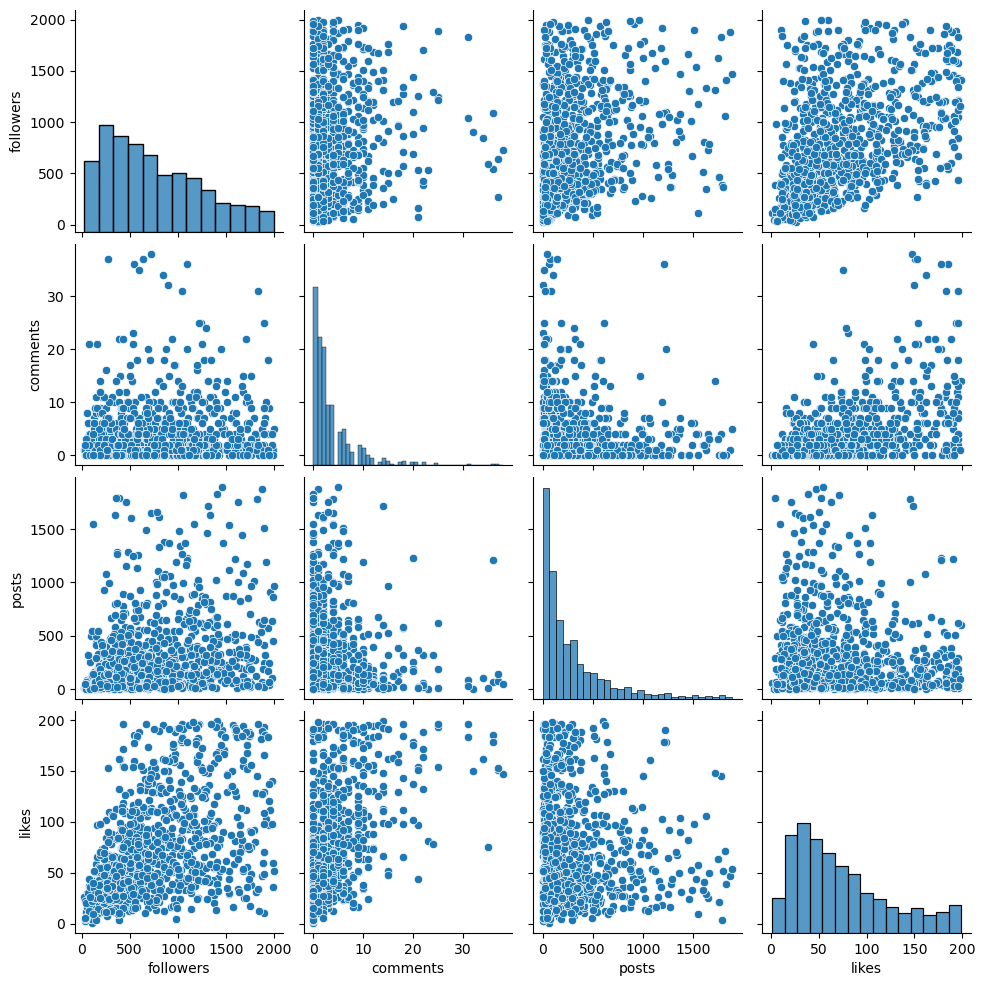

In [163]:
subsample_size = int(len(posts) / 10)
sns.pairplot(posts.sample(subsample_size))

<b>2.B)</b> Use this graph to answer the following questions:

- How are the likes distributed?

- What other variables are they related to? Do these relationships seem logical / explainable to you?

1. Lots of posts with only a few likes (less than 70). 

2. Number of followers

<b>2.C)</b> We now focus on the "followers" variable to predict "likes".

To confirm the intuition given by the pair-plot, we want to display the predicted variable ("likes") as a function of the explanatory variable ("followed"), accompanied by the marginal distribution of these two variables.

Complete the following code by replacing the `~~~~` with the correct variables.

In [164]:
import plotly.express as px

fig = px.density_heatmap(
    data_frame=posts,
    x=posts.followers,
    y=posts.likes,
    marginal_x="histogram",
    marginal_y="histogram",
)

fig.update_layout(height=700, width=700)

fig

<b>2.D)</b> Do you see a linear statistical relationship between the two variables? What do you think of the variance of this relationship?

Yes, but with a high variance

## 3. Separation into "train" and "test"

<b>3.A)</b> Separate the dataset into 80% random for training (`posts_train` variable) and 20% for testing (`posts_test` variable).

To do this, you can use the `train_test_split` function after importing it:

```
from sklearn.model_selection import train_test_split
```

In [165]:
# Separate datasets in train and test
df_posts_train, df_posts_test = train_test_split(
    posts,
    test_size=0.2,
    random_state=42,
)

features = ["followers"]
targets = ["likes"]
X_posts_train = df_posts_train[features]
y_posts_train = df_posts_train[targets]
X_posts_test = df_posts_test[features]
y_posts_test = df_posts_test[targets]

display(X_posts_train)
display(y_posts_train)
display(X_posts_test)
display(y_posts_test)

,followers
174546,1824
138695,513
1386137,508
1474896,1753
675537,294
...,...
669389,941
70346,455
616517,1314
678652,200


,likes
174546,68
138695,66
1386137,46
1474896,184
675537,125
...,...
669389,153
70346,65
616517,126
678652,32


,followers
629694,833
669335,239
671040,924
2183686,1221
582994,110
...,...
180875,316
194991,301
1772773,724
2103139,671


,likes
629694,64
669335,42
671040,130
2183686,117
582994,6
...,...
180875,53
194991,23
1772773,152
2103139,70


## 4. Modeling on the "train"

For our first model, we will use the variable with the greatest potential: the number of `followers`.

This first model will therefore predict the number of `likes` according to the number of `followers`.

The simplest model to predict this relationship is a linear model, which is expressed as:

```
number_of_likes = ( constant ) + ( coefficient x number_of_followers )
```

**Training** such a model is equivalent to **finding the values ​​of `constant` and `coefficient` that minimize the prediction error**.

<b>4.A)</b> Train such a linear model on the "train" sample.

In [166]:
linear_reg = linear_model.LinearRegression()
linear_reg.fit(X_posts_train, y_posts_train)

LinearRegression()

<b>4.B)</b> What is the value of the constant, also sometimes called the `intercept`?

How to interpret this value concretely? Explain its meaning in one sentence.

In [167]:
display(f"intercept_: {linear_reg.intercept_}")
# With 0 followers, you can expect 35 likes

'intercept_: [34.77841049]'

<b>4.C)</b> What is the value of the second parameter of this template, which is called `coefficient` in the above formula?

Explain in one sentence the interpretation of this value.

In [168]:
display(f"coef_: {linear_reg.coef_}")
# coef_ is the number of additional likes you can expect for 1 more follower
# Number of likes ± intercept_ + number of followers * coef_

'coef_: [[0.0491138]]'

<b>4.D)</b> Calculate the R2 score on the "train" sample? What is the MSE error? MAE error?

Does the model look good to you?

<details>
<summary><i>Click for a hint</i></summary>
    ⟿ you can either calculate the MSE and the MAE "by hand", or use the `mean_squared_error` and `mean_absolute_error` functions of the `sklearn.metrics` module .
</details>

In [169]:
y_train_pred = linear_reg.predict(X_posts_train)

# Identical to linear_reg.score(X_posts_train, y_posts_train)
r2score = metrics.r2_score(y_true=y_posts_train, y_pred=y_train_pred)
mse = metrics.mean_squared_error(y_true=y_posts_train, y_pred=y_train_pred)
mae = metrics.mean_absolute_error(y_true=y_posts_train, y_pred=y_train_pred)

likes_mean=y_posts_train.likes.mean()
display(f"r2score: {r2score}")
display(f"Error rate (MSE): {sqrt(mse) / likes_mean:.2%}")
display(f"MAE: {mae:.10f}")
display(f"Error rate (MAE): {mae / likes_mean:.2%}")

'r2score: 0.25483627629106653'

'Error rate (MSE): 57.44%'

'MAE: 32.3461928815'

'Error rate (MAE): 44.81%'

## 5. Application on the "test"

To validate the relevance of our model, we will now apply it to our "test" sample.

<b>5.A)</b> Use your model learned in the previous section to predict the values ​​on your "test". Plot these predictions in a graph as a function of the number of `followers`.

In [170]:
y_test_pred = linear_reg.predict(X_posts_test)
df_posts_test.loc[:, "predictions"] = y_test_pred
display(df_posts_test)

fig = px.scatter(
    df_posts_test,
    x="followers",
    y=["likes", "predictions"],
)
fig

,author_id,followers,comments,posts,likes,ts,predictions
629694,1b2e61a3,833,2,736,64,2019-03-07 21:49:54,75.690209
669335,c2261595,239,1,700,42,2019-02-22 16:32:00,46.516610
671040,d913b9c6,924,2,45,130,2019-03-09 10:38:42,80.159565
2183686,f842b6f0,1221,1,40,117,2019-03-06 07:50:30,94.746365
582994,a0988168,110,1,586,6,2019-03-08 13:14:39,40.180929
...,...,...,...,...,...,...,...
180875,2e9d6f6c,316,0,713,53,2019-03-10 18:36:25,50.298372
194991,f446284e,301,5,272,23,2019-03-06 13:52:38,49.561665
1772773,bed848c9,724,3,41,152,2019-03-10 10:45:01,70.336804
2103139,5f48d2a6,671,4,1259,70,2019-03-09 21:04:53,67.733773


<b>5.B)</b> Calculate the error metrics on the "test" and compare them with those obtained previously, in "train". Does your model show signs of overfitting?

In [171]:
# Identical to linear_reg.score(y_posts_test, y_posts_test)
r2score = metrics.r2_score(y_true=y_posts_test, y_pred=y_test_pred)
mse = metrics.mean_squared_error(y_true=y_posts_test, y_pred=y_test_pred)
mae = metrics.mean_absolute_error(y_true=y_posts_test, y_pred=y_test_pred)

likes_mean=y_posts_test.likes.mean()
display(f"r2score: {r2score}")
display(f"Error rate (MSE): {sqrt(mse) / likes_mean:.2%}")
display(f"MAE: {mae:.2f}")
display(f"Error rate (MAE): {mae / likes_mean:.2%}")

'r2score: 0.22535355641944432'

'Error rate (MSE): 59.98%'

'MAE: 33.45'

'Error rate (MAE): 46.41%'

# 6. Creating a Better Model

The previous model is very simple. It already delivers a certain value, because it makes it possible to highlight the link between the number of followers of an account and the number of likes of posts.

It does not show overfitting.

But its error is very large: 35 likes on average, while the likes of this dataset are distributed in a range from about 0 to about 200.

<b>6.A)</b> To make a better model, we will test a new explanatory variable.

In particular, the number of 'likes' posts have received in the past could be a good predictor of the 'likes' of a new post from the same account.

The code below:

1. reload the dataset from the `posts.csv.bz` archive
2. isolates the last post of each author, like what we did at the beginning of the TP
3. and associates *for each account* the median of the number of `likes` of all previous posts.

**Study the code below carefully to understand it, then run it.**

In [172]:
# loading the archive
archive = pd.read_csv('posts.csv.bz', compression='bz2')

# sort by chronological order
archive = archive.sort_values(by='ts', ascending=True)

# last_posts isolates the last post of each author
last_posts = archive.drop_duplicates('id', keep='last')

# we resume the archive, removing the last_ posts (thus keeping all the others)
posts_without_last = archive[~archive.index.isin(last_posts.index)]

# we calculate the median, by author, of the likes of previous posts
average_last_posts = posts_without_last.groupby('id', as_index=False)[['likes']].median()

# we rename this new variable (the historical median of likes) with a new name, so as not to create confusion
average_last_posts = average_last_posts.rename({'likes': 'likes_history'}, axis=1)

# we integrate this variable into the dataframe that contains the last post of each author
posts = last_posts.merge(average_last_posts, on="id")

# finally, to prepare the sequel, we create as before the "posts_train" and "posts_test" splits
posts_train, posts_test = train_test_split(posts, test_size=0.2, random_state=42,).copy()

<b>6.B)</b> Make a model that predicts the number of `likes` based on `likes_history`, the previous number of likes.

Is this model better than a model based on `followers`?

Conclude on the relevance of the `likes_history` variable to predict `likes`.

In [173]:
features = ["likes_history"]
target = ["likes"]
X_posts_train = posts_train[features]
y_posts_train = posts_train[target]
X_posts_test = posts_test[features]
y_posts_test = posts_test[target]

In [174]:
linear_history = linear_model.LinearRegression()
linear_history.fit(X_posts_train, y_posts_train)
y_train_pred = linear_history.predict(X_posts_train)

# Identical to linear_reg.score(X_posts_train, y_posts_train)
r2score = metrics.r2_score(y_true=y_posts_train, y_pred=y_train_pred)
mse = metrics.mean_squared_error(y_true=y_posts_train, y_pred=y_train_pred)
mae = metrics.mean_absolute_error(y_true=y_posts_train, y_pred=y_train_pred)

likes_mean=y_posts_train.likes.mean()
display(f"r2score: {r2score}")
display(f"Error rate (MSE): {sqrt(mse) / likes_mean:.2%}")
display(f"MAE: {mae:.2f}")
display(f"Error rate (MAE): {mae / likes_mean:.2%}")

'r2score: 0.5297306946316717'

'Error rate (MSE): 45.82%'

'MAE: 24.36'

'Error rate (MAE): 33.88%'

In [175]:
y_test_pred = linear_history.predict(X_posts_test)
posts_test.loc[:, "predictions"] = y_test_pred

fig = px.scatter(
    posts_test,
    x="likes_history",
    y=["likes", "predictions"],
)
fig

In [176]:
# Identical to linear_reg.score(y_posts_test, y_posts_test)
r2score = metrics.r2_score(y_true=y_posts_test, y_pred=y_test_pred)
mse = metrics.mean_squared_error(y_true=y_posts_test, y_pred=y_test_pred)
mae = metrics.mean_absolute_error(y_true=y_posts_test, y_pred=y_test_pred)

likes_mean=y_posts_test.likes.mean()
display(f"r2score: {r2score}")
display(f"Error rate (MSE): {sqrt(mse) / likes_mean:.2%}")
display(f"MAE: {mae:.2f}")
display(f"Error rate (MAE): {mae / likes_mean:.2%}")

'r2score: 0.5140512936697759'

'Error rate (MSE): 46.38%'

'MAE: 24.54'

'Error rate (MAE): 34.24%'

<b>6.C)</b> To conclude on linear models, make a model that predicts the number of likes based on the two explanatory variables tested so far:

- `likes_historical`
- `followers`

What do you think of this model?

In [177]:
# Redefine new data
features = ["likes_history", "followers"]
target = ["likes"]
X_posts_train = posts_train[features]
y_posts_train = posts_train[target]
X_posts_test = posts_test[features]
y_posts_test = posts_test[target]

linear_new = linear_model.LinearRegression()
linear_new.fit(X_posts_train, y_posts_train)
y_train_pred = linear_new.predict(X_posts_train)

# Identical to linear_reg.score(X_posts_train, y_posts_train)
r2score = metrics.r2_score(y_true=y_posts_train, y_pred=y_train_pred)
mse = metrics.mean_squared_error(y_true=y_posts_train, y_pred=y_train_pred)
mae = metrics.mean_absolute_error(y_true=y_posts_train, y_pred=y_train_pred)

likes_mean=y_posts_train.likes.mean()
display(f"r2score: {r2score}")
display(f"Error rate (MSE): {sqrt(mse) / likes_mean:.2%}")
display(f"MAE: {mae:.2f}")
display(f"Error rate (MAE): {mae / likes_mean:.2%}")

'r2score: 0.5615866085300572'

'Error rate (MSE): 44.24%'

'MAE: 23.49'

'Error rate (MAE): 32.67%'

<b>6.D)</b> Use this last model to predict the values ​​on your "test", and represent these predictions in a graph according to the number of `followers`.

In [ ]:
y_test_pred = linear_new.predict(X_posts_test)
posts_test.loc[:, "predictions"] = y_test_pred

fig = px.scatter(
    posts_test,
    x="likes_history",
    y=["likes", "predictions"],
    hover_data=["followers"]
)
fig

In [179]:
fig = px.scatter(
    posts_test,
    x="followers",
    y=["likes", "predictions"],
    hover_data=["likes_history"]
)
fig

In [180]:
# Identical to linear_reg.score(y_posts_test, y_posts_test)
r2score = metrics.r2_score(y_true=y_posts_test, y_pred=y_test_pred)
mse = metrics.mean_squared_error(y_true=y_posts_test, y_pred=y_test_pred)
mae = metrics.mean_absolute_error(y_true=y_posts_test, y_pred=y_test_pred)

likes_mean=y_posts_test.likes.mean()
display(f"r2score: {r2score}")
display(f"Error rate (MSE): {sqrt(mse) / likes_mean:.2%}")
display(f"MAE: {mae:.2f}")
display(f"Error rate (MAE): {mae / likes_mean:.2%}")

'r2score: 0.5571651369396614'

'Error rate (MSE): 44.27%'

'MAE: 23.41'

'Error rate (MAE): 32.66%'

# To go further: regression with other methods

Linear regression has been manipulated so far, because it is the most commonly used regression model in practice.

However, there are many other mathematical formulations.

Among the best known are:

- so-called "local" methods, which consist in the interpolation of the closest data points to predict the value of a new point;

- methods based on decision trees; predictions are made by traversing the successive nodes of a tree (each node is a branch, which determines the continuation of the traversal of the tree based on the values ​​of the explanatory variables).

Thanks to `sklearn` it is very easy to test these other methods on this problem.

<b>A)</b> Read the `KNeighborsRegressor` documentation [in the official documentation](
https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsRegressor.html#sklearn.neighbors.KNeighborsRegressor) and use this algorithm to predict the number of likes. Vary the `n_neighbors` setting. What do you observe?

<b>B)</b> Read the documentation for the `DecisionTreeRegressor` [in the official documentation](
https://scikit-learn.org/stable/auto_examples/tree/plot_tree_regression.html#sphx-glr-auto-examples-tree-plot-tree-regression-py) and use this algorithm to predict the number of likes based on `followers`. Vary the `max_depth` setting. What do you observe?